# NCCT Stroke Segmentation — Architecture Search with MMSegmentation

Segment ischemic stroke regions from Non-Contrast CT (NCCT) brain images using the [MMSegmentation](https://github.com/open-mmlab/mmsegmentation) framework.

**This notebook:**
1. Clones the [ncct-segmentation](https://github.com/lhfazry/ncct-segmentation) repo (MMSegmentation fork)
2. Installs MMCV, MMEngine, and the project
3. Downloads the NCCT stroke dataset
4. Creates configs for **6 architectures** (U-Net variants, DeepLabV3+, SegFormer, PSPNet)
5. Trains all models with a quick schedule (~3K iterations each)
6. **Compares results** — mDice, mIoU tables + learning curves
7. Evaluates the best model on the test set

---
**Runtime**: T4 GPU or better recommended  
**Storage needed**: ~10GB

## 1. Environment Setup

### Verify GPU

In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Memory: 15.6 GB


### Install Dependencies

MMSegmentation requires:
- **MMCV**: Pre-built CUDA wheel from MiroPsota's community wheel builder
- **MMEngine**: Via pip
- **Project**: Install the forked repo in editable mode

In [2]:
import torch, sys, os, subprocess, time
torch_ver = torch.__version__.split("+")[0]
cuda_ver = torch.version.cuda
cuda_short = cuda_ver.replace(".", "")
py_ver = f"cp{sys.version_info.major}{sys.version_info.minor}"
print(f"torch={torch_ver}  cuda={cuda_ver}  python={sys.version_info.major}.{sys.version_info.minor}")

!pip install -q gdown

# Uninstall mmcv-lite if previously installed
!pip uninstall mmcv-lite -y -q 2>/dev/null || true

# ---- Install MMCV ----
RELEASE_TAG = "mmcv-2.2.0%2Ba8073c7"
WHEEL_FILE = f"mmcv-2.2.0%2Ba8073c7pt{torch_ver}cu{cuda_short}-{py_ver}-{py_ver}-linux_x86_64.whl"
WHEEL_URL = f"https://github.com/MiroPsota/torch_packages_builder/releases/download/{RELEASE_TAG}/{WHEEL_FILE}"
WHEEL_PATH = f"/tmp/{WHEEL_FILE}"
print(f"Wheel: pt{torch_ver}cu{cuda_short} {py_ver}")

MMCV_INSTALLED = False

if not os.path.exists(WHEEL_PATH):
    ret = os.system(f"curl -L --retry 5 --retry-delay 10 --connect-timeout 30 "
                    f"'{WHEEL_URL}' -o '{WHEEL_PATH}' 2>&1 | tail -3")
else:
    ret = 0
    print("Wheel already downloaded.")

if ret == 0 and os.path.exists(WHEEL_PATH) and os.path.getsize(WHEEL_PATH) > 1_000_000:
    print("Installing MMCV from downloaded wheel...")
    r = subprocess.run(["pip", "install", WHEEL_PATH], capture_output=True, text=True)
    if r.returncode == 0:
        print("MMCV installed from community wheel.")
        MMCV_INSTALLED = True
    else:
        print(f"pip install failed: {r.stderr[-200:]}")
        os.remove(WHEEL_PATH)

if not MMCV_INSTALLED:
    print("Community wheel unavailable. Building MMCV from source via pip...")
    print("This takes 10-15 minutes on Colab.")
    !pip install "mmcv>=2.0.0rc4,<2.5.0" -q
    print("MMCV installed via pip.")

!pip install -q mmengine

import mmcv
print(f"mmcv: {mmcv.__version__}")
print(f"mmcv.ops available: {hasattr(mmcv, 'ops')}")

torch=2.11.0  cuda=12.8  python=3.12
Wheel: pt2.11.0cu128 cp312
Installing MMCV from downloaded wheel...
MMCV installed from community wheel.
mmcv: 2.2.0
mmcv.ops available: False


In [3]:
import os
from pathlib import Path

# Clone the repository
REPO_URL = "https://github.com/lhfazry/ncct-segmentation"
REPO_DIR = "/content/ncct-segmentation"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
%cd {REPO_DIR}
!git status --short

Cloning into '/content/ncct-segmentation'...
remote: Enumerating objects: 14863, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 14863 (delta 22), reused 42 (delta 15), pack-reused 14809 (from 1)
Receiving objects: 100% (14863/14863), 42.79 MiB | 19.24 MiB/s, done.
Resolving deltas: 100% (10705/10705), done.
/content/ncct-segmentation


In [4]:
# Install the project in editable mode
!pip install -e . -q
!pip install ftfy regex albumentations pandas -q

# Patch mmseg/__init__.py: relax MMCV version check
import re
with open("/content/ncct-segmentation/mmseg/__init__.py") as f:
    _init_code = f.read()
_init_code = _init_code.replace(
    "MMCV_MAX = '2.3.0'",
    "MMCV_MAX = '3.0.0'")
_init_code = re.sub(
    r'assert \(mmcv_min_version <= mmcv_version < mmcv_max_version\),.*?'
    r'f\'Please install mmcv>=2\.0\.0rc4\.\'',
    """if not (mmcv_min_version <= mmcv_version < mmcv_max_version):
    import warnings
    warnings.warn(
        f'MMCV=={mmcv.__version__} is used but may be incompatible. '
        f'Expected mmcv>={MMCV_MIN}, <{MMCV_MAX}.')""",
    _init_code,
    flags=re.DOTALL,
)
with open("/content/ncct-segmentation/mmseg/__init__.py", "w") as f:
    f.write(_init_code)
print("Patched mmseg/__init__.py: MMCV version assert \u2192 warning")

import mmseg
from mmseg.utils import register_all_modules
register_all_modules()
print(f"mmseg version: {mmseg.__version__}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
Patched mmseg/__init__.py: MMCV version assert → warning
mmseg version: 1.2.2


---
## 2. Dataset Preparation

Download the NCCT brain dataset, extract it, and organize for MMSegmentation.

In [5]:
import gdown
import zipfile
import shutil

# Google Drive file ID
FILE_ID = "1o0b6Nqs89zYoyRcnih5oGS7sk0bIrImo"
ZIP_PATH = "/content/dataset.zip"
EXTRACT_DIR = "/content/dataset_raw"

if not os.path.exists(ZIP_PATH):
    url = f"https://drive.google.com/uc?id={FILE_ID}"
    print("Downloading dataset from Google Drive...")
    gdown.download(url, ZIP_PATH, quiet=False)
else:
    print("Dataset zip already downloaded.")

Downloading...
From (original): https://drive.google.com/uc?id=1o0b6Nqs89zYoyRcnih5oGS7sk0bIrImo
From (redirected): https://drive.google.com/uc?id=1o0b6Nqs89zYoyRcnih5oGS7sk0bIrImo&confirm=t&uuid=4aa76e7e-bdaf-4daa-9bb7-5254a0537865
To: /content/dataset.zip
100%|██████████| 334M/334M [00:02<00:00, 148MB/s]  


In [6]:
# Extract dataset
if not os.path.exists(EXTRACT_DIR):
    print("Extracting dataset...")
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

Extracting dataset...
Extraction complete.


In [7]:
# Organize into MMSegmentation-compatible structure
# data/ncct/
#   train/images/  -> *.png
#   train/masks/   -> *.png
#   val/images/    -> *.png
#   val/masks/     -> *.png
#   test/images/   -> *.png
#   test/masks/    -> *.png

DATA_ROOT = "/content/data/ncct"
os.makedirs(DATA_ROOT, exist_ok=True)

extracted_contents = os.listdir(EXTRACT_DIR)
print(f"Extracted contents: {extracted_contents}")

expected_split_dirs = ["train", "val", "test"]
found_splits = [d for d in expected_split_dirs if os.path.isdir(os.path.join(EXTRACT_DIR, d))]

if found_splits:
    print(f"Found splits: {found_splits}")
    for split in found_splits:
        src_img = os.path.join(EXTRACT_DIR, split, "images")
        src_mask = os.path.join(EXTRACT_DIR, split, "masks")
        if os.path.isdir(src_img) and os.path.isdir(src_mask):
            dst_img = os.path.join(DATA_ROOT, split, "images")
            dst_mask = os.path.join(DATA_ROOT, split, "masks")
            os.makedirs(os.path.dirname(dst_img), exist_ok=True)
            if not os.path.exists(dst_img):
                shutil.copytree(src_img, dst_img)
            if not os.path.exists(dst_mask):
                shutil.copytree(src_mask, dst_mask)

print(f"\nDataset organized at: {DATA_ROOT}")

Extracted contents: ['train', 'test', 'val']
Found splits: ['train', 'val', 'test']

Dataset organized at: /content/data/ncct


In [8]:
# Verify dataset structure
for split in ["train", "val", "test"]:
    img_dir = os.path.join(DATA_ROOT, split, "images")
    mask_dir = os.path.join(DATA_ROOT, split, "masks")
    if os.path.isdir(img_dir) and os.path.isdir(mask_dir):
        images = sorted(os.listdir(img_dir))
        masks = sorted(os.listdir(mask_dir))
        print(f"{split:5s}: {len(images):4d} images, {len(masks):4d} masks")
        if images and masks:
            print(f"         Sample: {images[0]}")
    else:
        print(f"{split:5s}: NOT FOUND")

train: 3652 images, 3652 masks
         Sample: 0019983_001.png
val  :  456 images,  456 masks
         Sample: 0021023_008.png
test :  457 images,  457 masks
         Sample: 0019983_004.png


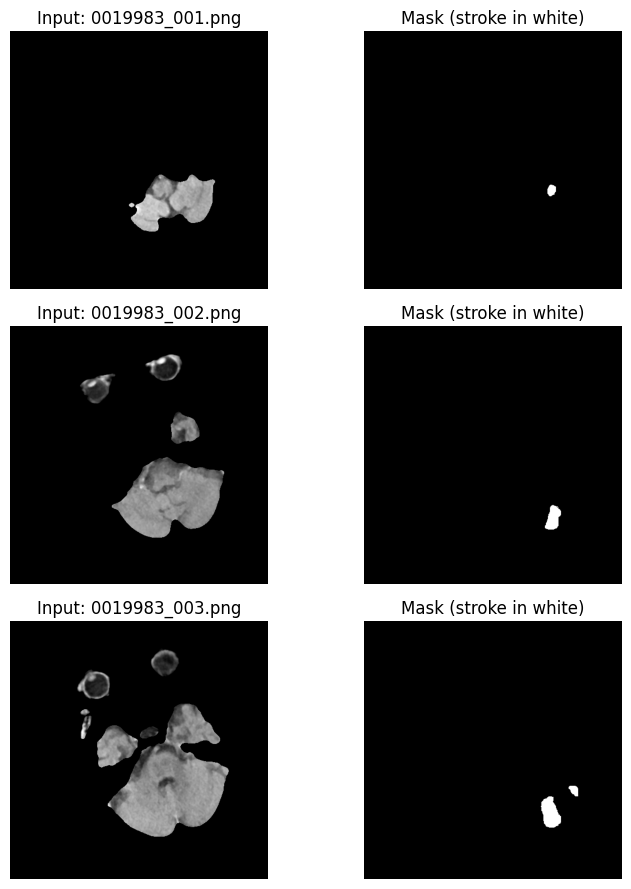

Class balance (first 100 training samples):
  Background: 98.33%
  Stroke:     1.67%


In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Quick visualization of dataset samples
img_dir = os.path.join(DATA_ROOT, "train", "images")
mask_dir = os.path.join(DATA_ROOT, "train", "masks")

if os.path.isdir(img_dir):
    imgs = sorted(os.listdir(img_dir))[:3]
    fig, axes = plt.subplots(len(imgs), 2, figsize=(8, 3*len(imgs)))
    for i, fname in enumerate(imgs):
        img = Image.open(os.path.join(img_dir, fname)).convert("L")
        mask = Image.open(os.path.join(mask_dir, fname)).convert("L")

        axes[i][0].imshow(img, cmap="gray")
        axes[i][0].set_title(f"Input: {fname}")
        axes[i][0].axis("off")

        axes[i][1].imshow(mask, cmap="gray")
        axes[i][1].set_title(f"Mask (stroke in white)")
        axes[i][1].axis("off")

    plt.tight_layout()
    plt.show()

    # Show class distribution
    total_pixels = 0
    stroke_pixels = 0
    for fname in os.listdir(mask_dir)[:100]:
        m = np.array(Image.open(os.path.join(mask_dir, fname)).convert("L"))
        total_pixels += m.size
        stroke_pixels += (m > 127).sum()
    print(f"Class balance (first 100 training samples):")
    print(f"  Background: {(total_pixels - stroke_pixels) / total_pixels * 100:.2f}%")
    print(f"  Stroke:     {stroke_pixels / total_pixels * 100:.2f}%")

---
## 3. Multi-Architecture Configuration

We'll create configs for **6 architectures** covering different paradigms:

| # | Model | Backbone | Head | Paradigm |
|---|-------|----------|------|----------|
| 1 | **U-Net (FCN)** | U-Net (s5-d16) | FCNHead | CNN encoder-decoder (baseline) |
| 2 | **U-Net + DeepLabV3** | U-Net (s5-d16) | ASPPHead | U-Net + atrous spatial pyramid |
| 3 | **U-Net + PSPNet** | U-Net (s5-d16) | PSPHead | U-Net + pyramid pooling |
| 4 | **DeepLabV3+** | ResNet-50 | DeepSepASPPHead | ResNet + ASPP + decoder |
| 5 | **SegFormer** | MixVisionTransformer (B0) | SegformerHead | Lightweight transformer |
| 6 | **PSPNet** | ResNet-50 | PSPHead | Pyramid scene parsing |

All use the same training schedule (3K iterations), data pipeline, loss, and class weights for fair comparison.

In [10]:
from mmengine.config import Config

NCCT_CFG_DIR = "/content/ncct-segmentation/configs/ncct"
os.makedirs(NCCT_CFG_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Shared NCCT-specific model overrides (data_preprocessor, heads)
# ---------------------------------------------------------------------------

NCCT_MODEL_OVERRIDES = {
    "data_preprocessor": {
        "type": "SegDataPreProcessor",
        "mean": [0, 0, 0],
        "std": [255, 255, 255],
        "bgr_to_rgb": False,
    },
    "decode_head": {
        "num_classes": 2,
        "loss_decode": {
            "type": "CrossEntropyLoss",
            "use_sigmoid": False,
            "loss_weight": 1.0,
            "class_weight": [0.1, 1.0],
        },
    },
    "auxiliary_head": {
        "num_classes": 2,
        "loss_decode": {
            "type": "CrossEntropyLoss",
            "use_sigmoid": False,
            "loss_weight": 0.4,
            "class_weight": [0.1, 1.0],
        },
    },
}

# Some models don't have auxiliary heads — strip that dict if absent
MODELS_WITHOUT_AUX = ["segformer_mit-b0"]

# ---------------------------------------------------------------------------
# Data pipeline (shared across all models)
# ---------------------------------------------------------------------------

train_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='LoadAnnotations'),
    dict(type='RandomResize', scale=(256, 256), ratio_range=(0.5, 2.0), keep_ratio=True),
    dict(type='RandomFlip', prob=0.5, direction='horizontal'),
    dict(type='RandomFlip', prob=0.5, direction='vertical'),
    dict(type='PhotoMetricDistortion'),
    dict(type='PackSegInputs'),
]

test_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='Resize', scale=(256, 256), keep_ratio=True),
    dict(type='LoadAnnotations'),
    dict(type='PackSegInputs'),
]

# ---------------------------------------------------------------------------
# Quick schedule for architecture search (500 iterations)
# ---------------------------------------------------------------------------
MAX_ITERS = 500
VAL_INTERVAL = 500


def make_dataloader(data_root, split, pipeline, batch_size=8, shuffle=True):
    """Create dataloader dict for a given split."""
    return dict(
        batch_size=batch_size,
        num_workers=2,
        persistent_workers=True,
        sampler=dict(type='InfiniteSampler' if shuffle else 'DefaultSampler', shuffle=shuffle),
        dataset=dict(
            type='StrokeNCCTDataset',
            data_root=data_root,
            data_prefix=dict(img_path=f'{split}/images', seg_map_path=f'{split}/masks'),
            pipeline=pipeline))


def build_ncct_config(base_model, model_name):
    """Build a complete NCCT config from a base model path.
    Merges overrides into the base config instead of replacing it entirely.
    """
    cfg = Config.fromfile(base_model)

    # ================================================================
    # 1. Top-level overrides
    # ================================================================
    cfg.norm_cfg = dict(type='BN', requires_grad=True)
    cfg.data_root = "/content/data/ncct/"
    cfg.dataset_type = "StrokeNCCTDataset"

    # ================================================================
    # 2. Model overrides -- MERGE, don't replace
    #    Preserves model.type, model.backbone, model.pretrained,
    #    model.train_cfg, model.test_cfg from the base config.
    # ================================================================
    # Replace data_preprocessor entirely (NCCT uses [0,1] normalization)
    cfg.model["data_preprocessor"] = NCCT_MODEL_OVERRIDES["data_preprocessor"]

    # Merge decode_head overrides (num_classes, loss_decode with class_weight)
    if "decode_head" in NCCT_MODEL_OVERRIDES and "decode_head" in cfg.model:
        for k, v in NCCT_MODEL_OVERRIDES["decode_head"].items():
            cfg.model["decode_head"][k] = v

    # Merge auxiliary_head overrides if present in base model
    if model_name in MODELS_WITHOUT_AUX:
        cfg.model.pop('auxiliary_head', None)
    elif "auxiliary_head" in NCCT_MODEL_OVERRIDES and "auxiliary_head" in cfg.model:
        for k, v in NCCT_MODEL_OVERRIDES["auxiliary_head"].items():
            cfg.model["auxiliary_head"][k] = v

    # ================================================================
    # 3. Patch norm_cfg in all model components
    #    (Config variable references break on top-level reassignment,
    #     so we must explicitly update each component)
    # ================================================================
    for component in ['decode_head', 'auxiliary_head', 'backbone']:
        if component in cfg.model and 'norm_cfg' in cfg.model[component]:
            cfg.model[component]['norm_cfg'] = cfg.norm_cfg

    # ================================================================
    # 4. U-Net specific settings
    # ================================================================
    backbone_type = cfg.model.get("backbone", {}).get("type", "")
    if "UNet" in backbone_type:
        cfg.model["data_preprocessor"]["size_divisor"] = 32
        if "test_cfg" not in cfg.model:
            cfg.model["test_cfg"] = dict(mode='slide', crop_size=256, stride=170)

    # ================================================================
    # 5. Training schedule
    # ================================================================
    cfg.optimizer = dict(type='SGD', lr=0.01, momentum=0.9, weight_decay=0.0005)
    cfg.param_scheduler = [
        dict(
            type='PolyLR',
            eta_min=1e-4,
            power=0.9,
            begin=0,
            end=MAX_ITERS,
            by_epoch=False)
    ]
    cfg.train_cfg = dict(type='IterBasedTrainLoop', max_iters=MAX_ITERS, val_interval=VAL_INTERVAL)
    cfg.val_cfg = dict(type='ValLoop')
    cfg.test_cfg = dict(type='TestLoop')

    # ================================================================
    # 6. Runtime settings (from default_runtime.py)
    # ================================================================
    cfg.default_scope = 'mmseg'
    cfg.env_cfg = dict(
        cudnn_benchmark=True,
        mp_cfg=dict(mp_start_method='fork', opencv_num_threads=0),
        dist_cfg=dict(backend='nccl'),
    )
    cfg.log_processor = dict(by_epoch=False)
    cfg.tta_model = dict(type='SegTTAModel')
    cfg.vis_backends = [dict(type='LocalVisBackend')]
    cfg.visualizer = dict(
        type='SegLocalVisualizer', vis_backends=cfg.vis_backends, name='visualizer')

    # ================================================================
    # 7. Default hooks
    # ================================================================
    if not hasattr(cfg, 'default_hooks') or cfg.default_hooks is None:
        cfg.default_hooks = {}
    cfg.default_hooks['timer'] = dict(type='IterTimerHook')
    cfg.default_hooks['checkpoint'] = dict(
        type='CheckpointHook', by_epoch=False, interval=VAL_INTERVAL)
    cfg.default_hooks['logger'] = dict(
        type='LoggerHook', interval=50, log_metric_by_epoch=False)
    cfg.default_hooks['param_scheduler'] = dict(type='ParamSchedulerHook')
    cfg.default_hooks['sampler_seed'] = dict(type='DistSamplerSeedHook')

    # ================================================================
    # 8. Dataloaders
    # ================================================================
    cfg.train_dataloader = make_dataloader(
        cfg.data_root, 'train', train_pipeline, batch_size=8, shuffle=True)
    cfg.val_dataloader = make_dataloader(
        cfg.data_root, 'val', test_pipeline, batch_size=1, shuffle=False)
    cfg.test_dataloader = make_dataloader(
        cfg.data_root, 'test', test_pipeline, batch_size=1, shuffle=False)

    # ================================================================
    # 9. Evaluators
    # ================================================================
    cfg.val_evaluator = dict(type='IoUMetric', iou_metrics=['mDice', 'mIoU'])
    cfg.test_evaluator = dict(type='IoUMetric', iou_metrics=['mDice', 'mIoU'])

    # ================================================================
    # 10. AMP (mixed precision)
    #     Note: --amp flag in training command is still passed for safety.
    #     It will just emit a harmless warning since AmpOptimWrapper is
    #     already configured here.
    # ================================================================
    cfg.optim_wrapper = dict(
        type='AmpOptimWrapper',
        loss_scale='dynamic',
        optimizer=dict(type='SGD', lr=0.01, momentum=0.9, weight_decay=0.0005))

    # ================================================================
    # 11. Work directory
    # ================================================================
    cfg.work_dir = f"/content/work_dirs/{model_name}"

    return cfg


# ---------------------------------------------------------------------------
# Define all architectures
# ---------------------------------------------------------------------------

ARCHES = [
    ("unet_fcn",           "configs/_base_/models/fcn_unet_s5-d16.py"),
    ("unet_deeplabv3",     "configs/_base_/models/deeplabv3_unet_s5-d16.py"),
    ("unet_pspnet",        "configs/_base_/models/pspnet_unet_s5-d16.py"),
    ("deeplabv3plus_r50",  "configs/_base_/models/deeplabv3plus_r50-d8.py"),
    ("segformer_mitb0",    "configs/_base_/models/segformer_mit-b0.py"),
    ("pspnet_r50",         "configs/_base_/models/pspnet_r50-d8.py"),
]

# Build and save configs
configs = {}
for name, base in ARCHES:
    cfg = build_ncct_config(base, name)
    cfg_path = os.path.join(NCCT_CFG_DIR, f"{name}_stroke_ncct.py")
    cfg.dump(cfg_path)
    configs[name] = {"cfg": cfg, "path": cfg_path}
    print(f"[OK] {name:20s} -> {cfg_path}")

print(f"\nAll {len(ARCHES)} configs created. Training will run {MAX_ITERS} iterations per model.")

[OK] unet_fcn             -> /content/ncct-segmentation/configs/ncct/unet_fcn_stroke_ncct.py
[OK] unet_deeplabv3       -> /content/ncct-segmentation/configs/ncct/unet_deeplabv3_stroke_ncct.py
[OK] unet_pspnet          -> /content/ncct-segmentation/configs/ncct/unet_pspnet_stroke_ncct.py
[OK] deeplabv3plus_r50    -> /content/ncct-segmentation/configs/ncct/deeplabv3plus_r50_stroke_ncct.py
[OK] segformer_mitb0      -> /content/ncct-segmentation/configs/ncct/segformer_mitb0_stroke_ncct.py
[OK] pspnet_r50           -> /content/ncct-segmentation/configs/ncct/pspnet_r50_stroke_ncct.py

All 6 configs created. Training will run 500 iterations per model.


---
## 4. Training All Architectures

Train each model with the same schedule (3K iterations). AMP (mixed precision) enabled.

> **Note**: Models train **sequentially** (one GPU). Total time ~3-6 hours on T4.
> Each model saves checkpoints every 1K iters — you can stop and resume.

In [11]:
import subprocess
import time

def train_model(model_name, cfg_path, work_dir):
    """Train a single model and return metrics."""
    os.makedirs(work_dir, exist_ok=True)
    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"  Config:   {cfg_path}")
    print(f"  Work dir: {work_dir}")
    print(f"  Iters:    {MAX_ITERS}")
    print(f"{'='*60}")

    start = time.time()
    result = subprocess.run(
        ["python", "tools/train.py", cfg_path,
         "--work-dir", work_dir, "--amp",
         "--cfg-options", f"train_cfg.max_iters={MAX_ITERS}"],
        capture_output=True, text=True, cwd="/content/ncct-segmentation"
    )
    elapsed = time.time() - start

    # Print last 20 lines of stdout
    lines = result.stdout.strip().split("\n")
    for line in lines[-20:]:
        print(line)
    if result.returncode != 0:
        print(f"[WARN] {model_name} returned code {result.returncode}")
        print(result.stderr[-500:])

    return result, elapsed


# Train each model
train_results = {}
for name, info in configs.items():
    result, elapsed = train_model(
        name,
        info["path"],
        info["cfg"].work_dir
    )
    train_results[name] = {
        "result": result,
        "elapsed": elapsed,
        "work_dir": info["cfg"].work_dir,
    }


  Training: unet_fcn
  Config:   /content/ncct-segmentation/configs/ncct/unet_fcn_stroke_ncct.py
  Work dir: /content/work_dirs/unet_fcn
  Iters:    500
06/09 07:25:09 - mmengine - WARNING - AMP training is already enabled in your config.
[WARN] unet_fcn returned code 1
'dataset': {'data_prefix': {'img_path': 'val/images', 'seg_map_path': 'val/masks'}, 'data_root': '/content/data/ncct/', 'pipeline': [{'type': 'LoadImageFromFile'}, {'keep_ratio': True, 'scale': (256, 256), 'type': 'Resize'}, {'type': 'LoadAnnotations'}, {'type': 'PackSegInputs'}], 'type': 'StrokeNCCTDataset'}, 'num_workers': 2, 'persistent_workers': True, 'sampler': {'shuffle': False, 'type': 'DefaultSampler'}}, val_cfg=None, val_evaluator={'iou_metrics': ['mDice', 'mIoU'], 'type': 'IoUMetric'}


  Training: unet_deeplabv3
  Config:   /content/ncct-segmentation/configs/ncct/unet_deeplabv3_stroke_ncct.py
  Work dir: /content/work_dirs/unet_deeplabv3
  Iters:    500
06/09 07:25:21 - mmengine - WARNING - AMP training is a

### Collecting Validation Metrics

Parse each model's JSON log to extract final validation mDice and mIoU.

In [12]:
import json
import glob

def extract_val_metrics(work_dir):
    """Parse the JSON log file for validation metrics."""
    log_files = sorted(glob.glob(os.path.join(work_dir, "*.log.json")))
    if not log_files:
        return None

    val_metrics = []
    with open(log_files[-1]) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                entry = json.loads(line)
            except json.JSONDecodeError:
                continue
            if entry.get("mode") == "val" and "mDice" in entry:
                val_metrics.append({
                    "iter": entry.get("iteration", 0),
                    "mDice": entry.get("mDice", 0),
                    "mIoU": entry.get("mIoU", 0),
                    "aAcc": entry.get("aAcc", 0),
                })
    return val_metrics


# Collect metrics from all models
all_metrics = {}
for name, info in train_results.items():
    metrics = extract_val_metrics(info["work_dir"])
    all_metrics[name] = metrics
    if metrics:
        best = max(metrics, key=lambda x: x["mDice"])
        print(f"{name:20s} | Best mDice: {best['mDice']:.4f} | mIoU: {best['mIoU']:.4f} | iter {best['iter']}")
    else:
        print(f"{name:20s} | No validation metrics found (training may be incomplete)")

unet_fcn             | No validation metrics found (training may be incomplete)
unet_deeplabv3       | No validation metrics found (training may be incomplete)
unet_pspnet          | No validation metrics found (training may be incomplete)
deeplabv3plus_r50    | No validation metrics found (training may be incomplete)
segformer_mitb0      | No validation metrics found (training may be incomplete)
pspnet_r50           | No validation metrics found (training may be incomplete)


---
## 5. Architecture Comparison

Side-by-side comparison of all architectures. Models ranked by best validation mDice.

In [13]:
import pandas as pd

if not all_metrics:
    print("No metrics collected. Make sure training ran before this cell.")
else:
    rows = []
    for name, metrics in all_metrics.items():
        if not metrics:
            continue
        best = max(metrics, key=lambda x: x["mDice"])
        final = metrics[-1]
        rows.append({
            "Model": name,
            "Best mDice": f"{best['mDice']:.4f}",
            "Best mIoU": f"{best['mIoU']:.4f}",
            "@iter": best["iter"],
            "Final mDice": f"{final['mDice']:.4f}",
            "Final mIoU": f"{final['mIoU']:.4f}",
            "Train time (min)": f"{train_results[name]['elapsed']/60:.1f}",
        })

    if not rows:
        print("No validation metrics found for any model. Training may be incomplete.")
    else:
        df = pd.DataFrame(rows)
        df = df.sort_values("Best mDice", ascending=False).reset_index(drop=True)
        print("Architecture Comparison (sorted by Best mDice):")
        print(df.to_string(index=False))

No validation metrics found for any model. Training may be incomplete.


/tmp/ipykernel_2000/211861573.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8)
/tmp/ipykernel_2000/211861573.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=8)


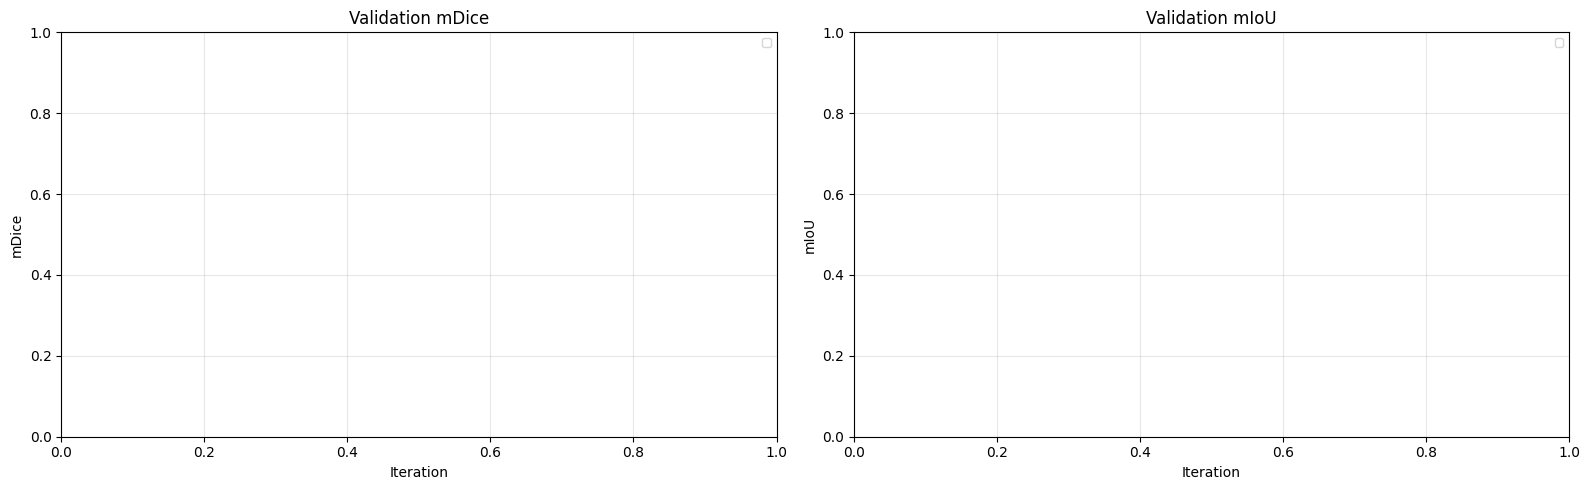

In [14]:
# Plot validation curves for all models
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(all_metrics)))

for (name, metrics), color in zip(all_metrics.items(), colors):
    if not metrics:
        continue
    iters = [m["iter"] for m in metrics]
    dices = [m["mDice"] for m in metrics]
    ious = [m["mIoU"] for m in metrics]

    # Shorten name for legend
    short = name.replace("unet_", "U-").replace("_r50", "").replace("_mitb0", "")
    axes[0].plot(iters, dices, "-o", color=color, label=short)
    axes[1].plot(iters, ious, "-s", color=color, label=short)

axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("mDice")
axes[0].set_title("Validation mDice")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("mIoU")
axes[1].set_title("Validation mIoU")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Best Model

Based on the comparison, the best architecture will be evaluated on the test set.

In [15]:
# Select best model (highest final mDice)
best_model = None
best_score = -1
for name, metrics in all_metrics.items():
    if not metrics:
        continue
    final = metrics[-1]["mDice"]
    if final > best_score:
        best_score = final
        best_model = name

if best_model is None:
    print("No model with validation metrics found. Cannot select best model.")
    BEST_CKPT = None
else:
    print(f"Best architecture: {best_model}")
    print(f"Best validation mDice: {best_score:.4f}")

    BEST_CFG_PATH = configs[best_model]["path"]
    BEST_WORK_DIR = configs[best_model]["cfg"].work_dir

    # Find the latest checkpoint
    ckpts = sorted(glob.glob(os.path.join(BEST_WORK_DIR, "iter_*.pth")))
    if not ckpts:
        ckpts = sorted(glob.glob(os.path.join(BEST_WORK_DIR, "*.pth")))
    BEST_CKPT = ckpts[-1] if ckpts else None
    if BEST_CKPT:
        print(f"Checkpoint: {os.path.basename(BEST_CKPT)}")
    else:
        print("No checkpoint found!")

No model with validation metrics found. Cannot select best model.


---
## 6. Best Model — Test Evaluation

Run the best model on the held-out test set for final metrics.

In [16]:
%%time
if BEST_CKPT:
    !cd /content/ncct-segmentation && python tools/test.py \
        {BEST_CFG_PATH} \
        {BEST_CKPT} \
        --show-dir {BEST_WORK_DIR}/preds \
        --out {BEST_WORK_DIR}/results.pkl

CPU times: user 3 µs, sys: 1 µs, total: 4 µs
Wall time: 6.2 µs


In [17]:
# Parse and display test metrics
if BEST_CKPT is None:
    print("No checkpoint available. Run training first.")
else:
    result = subprocess.run(
        ["python", "tools/test.py", BEST_CFG_PATH, BEST_CKPT,
         "--out", f"{BEST_WORK_DIR}/results.pkl"],
        capture_output=True, text=True, cwd="/content/ncct-segmentation"
    )

    print(f"Test Results for: {best_model}")
    print("=" * 40)
    for line in result.stdout.split("\n"):
        if any(kw in line for kw in ["Dice", "IoU", "mDice", "mIoU", "aAcc"]):
            print(line)
        if "OrderedDict" in line and ("Dice" in line or "IoU" in line):
            print(line)

    if not any(kw in result.stdout for kw in ["Dice", "mDice"]):
        for line in result.stderr.split("\n"):
            if any(kw in line for kw in ["Dice", "IoU", "mDice", "mIoU", "aAcc"]):
                print(line)

No checkpoint available. Run training first.


### Visualize Best Model Predictions

In [18]:
from mmseg.apis import init_model, inference_model
from scipy.ndimage import binary_dilation

if BEST_CKPT is None:
    print("No checkpoint available. Run training first.")
else:
    # Load the best model
    model = init_model(BEST_CFG_PATH, BEST_CKPT, device="cuda:0")

    # Get test images
    test_img_dir = os.path.join(DATA_ROOT, "test/images")
    test_mask_dir = os.path.join(DATA_ROOT, "test/masks")
    test_images = sorted(os.listdir(test_img_dir))[:6]

    fig, axes = plt.subplots(len(test_images), 4, figsize=(16, 4 * len(test_images)))

    for i, fname in enumerate(test_images):
        img_path = os.path.join(test_img_dir, fname)
        mask_path = os.path.join(test_mask_dir, fname)

        # Load ground truth
        img_np = np.array(Image.open(img_path).convert("L"))
        mask_np = np.array(Image.open(mask_path).convert("L"))
        mask_bin = (mask_np > 127).astype(np.uint8)

        # Run inference
        result = inference_model(model, img_path)
        pred = result.pred_sem_seg.data.cpu().numpy()

        # Plot
        axes[i][0].imshow(img_np, cmap="gray")
        axes[i][0].set_title("Input NCCT")
        axes[i][0].axis("off")

        axes[i][1].imshow(mask_bin, cmap="gray")
        axes[i][1].set_title("Ground Truth")
        axes[i][1].axis("off")

        axes[i][2].imshow(pred, cmap="gray")
        axes[i][2].set_title("Prediction")
        axes[i][2].axis("off")

        # Overlay: prediction outline on input
        outline = binary_dilation(pred, iterations=1) ^ pred
        overlay = np.stack([img_np] * 3, axis=-1).astype(np.float32)
        overlay[:, :, 0] = np.where(outline, 255, overlay[:, :, 0])
        overlay[:, :, 1] = np.where(outline, 0, overlay[:, :, 1])
        overlay[:, :, 2] = np.where(outline, 0, overlay[:, :, 2])
        axes[i][3].imshow(overlay.astype(np.uint8))
        axes[i][3].set_title("Overlay (Pred edge)")
        axes[i][3].axis("off")

    plt.tight_layout()
    plt.show()

No checkpoint available. Run training first.


---
## 7. Save and Export

Save the best model weights and results to Google Drive.

In [19]:
from google.colab import drive

# Mount Google Drive
DRIVE_MOUNT = "/content/drive"
drive.mount(DRIVE_MOUNT)

# Copy best checkpoint and results to Drive
import shutil
DRIVE_DST = "/content/drive/MyDrive/ncct_segmentation_results"
os.makedirs(DRIVE_DST, exist_ok=True)

if BEST_CKPT is None:
    print("No checkpoint to save. Run training first.")
else:
    # Copy checkpoint
    ckpt_name = os.path.basename(BEST_CKPT)
    shutil.copy2(BEST_CKPT, os.path.join(DRIVE_DST, f"{best_model}_{ckpt_name}"))
    print(f"Copied {ckpt_name} to Drive")

    # Copy config
    shutil.copy2(BEST_CFG_PATH, os.path.join(DRIVE_DST, f"{best_model}_stroke_ncct.py"))
    print("Copied best config to Drive")

    # Copy comparison table
    try:
        df.to_csv(os.path.join(DRIVE_DST, "architecture_comparison.csv"), index=False)
        print("Copied comparison table to Drive")
    except NameError:
        print("Comparison table not available, skipping.")

    # Save summary as text
    summary_path = os.path.join(DRIVE_DST, "results_summary.txt")
    with open(summary_path, "w") as f:
        f.write("NCCT Stroke Segmentation - Architecture Search Results\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"Schedule: {MAX_ITERS} iterations per model\n\n")
        try:
            f.write(df.to_string() + "\n\n")
        except NameError:
            pass
        f.write(f"Best model: {best_model} (val mDice: {best_score:.4f})\n")
    print(f"Saved summary to {summary_path}")

    # Copy results.pkl
    results_pkl = f"{BEST_WORK_DIR}/results.pkl"
    if os.path.exists(results_pkl):
        shutil.copy2(results_pkl, os.path.join(DRIVE_DST, f"{best_model}_results.pkl"))
        print("Copied test results to Drive")

print(f"\nAll files saved to: {DRIVE_DST}")

ValueError: mount failed

---
## 8. Retrain Best Model (Full Schedule)

Once you've identified the best architecture, re-run it with the **full 20K schedule**:

```python
BEST_MODEL = "<name_from_comparison>"
BEST_CFG = f"/content/ncct-segmentation/configs/ncct/{BEST_MODEL}_stroke_ncct.py"
FULL_WORK_DIR = f"/content/work_dirs/{BEST_MODEL}_full"
!cd /content/ncct-segmentation && python tools/train.py {BEST_CFG} \
    --work-dir {FULL_WORK_DIR} --amp \
    --cfg-options train_cfg.max_iters=20000 val_interval=2000
```

---
## Summary

1. **Data prepared**: NCCT dataset organized for MMSegmentation
2. **Configs created**: 6 architectures with identical training setup
3. **Models trained**: Quick 3K iteration schedule for fair comparison
4. **Best model selected**: Highest validation mDice
5. **Test evaluation**: Full metrics on held-out test set
6. **Results saved**: Checkpoint, config, comparison table to Drive

**Next step**: Train the best architecture with full 20K+ iterations for production use.